# Ejercicio 1
Implemente un perceptrón simple que aprenda la función lógica AND y la función
lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el
entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos
los vectores de entrada de la red.

In [129]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=1):
        self.weights = np.zeros(input_size + 1)  # +1 para el bias
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors = []

    def predict(self, X):
        h = np.dot(X, self.weights[1:]) + self.weights[0]  # w0 es el bias
        return np.where(h >= 0, 1, -1)

    def train(self, X, y):
        for _ in range(self.epochs):
            # Desordenar los datos al inicio de cada época
            indices = np.random.permutation(len(X))
            X = X[indices]
            y = y[indices]

            E = 0
            for xi, target in zip(X, y):
                y_pred = self.predict(xi)
                error = target - y_pred
                self.weights[1:] += self.learning_rate * error * xi
                self.weights[0] += self.learning_rate * error  # Ajuste del bias
                E += (error**2)/2
            self.errors.append(E)
            
            if E == 0:  # Si no hay errores, detener el entrenamiento
                break
        return E

    def plot_decision_boundary(self, X, y , title):
        # Definir los valores de x1
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        x1_vals = np.linspace(x1_min, x1_max, 100)

        # Ecuación de la recta: w0 + w1 * x1 + w2 * x2 = 0 => x2 = -(w0 + w1 * x1) / w2
        x2_vals = -(self.weights[0] + self.weights[1] * x1_vals) / self.weights[2]

        # Gráfico de los puntos y la recta
        plt.plot(x1_vals, x2_vals, 'b-', label='Recta discriminadora')
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', marker='o', label='Clase 1')
        plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='g', marker='x', label='Clase -1')

        plt.xlim([x1_min, x1_max])
        plt.ylim([x2_min, x2_max])
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.legend()
        plt.title(f'Recta discriminadora y puntos - {title}')
        plt.grid(True)
        plt.show()

    # Grafico la evolución del error por iteracion
    def plot_error(self,title):
        plt.figure(figsize=(8,6))
        plt.plot(self.errors)
        plt.xlabel('Epoca')
        plt.ylabel('Error')
        plt.title(f'Evolución del Error durante el entrenamiento - {title}')
        plt.grid(True)
        plt.show()


### Caso compuerta AND

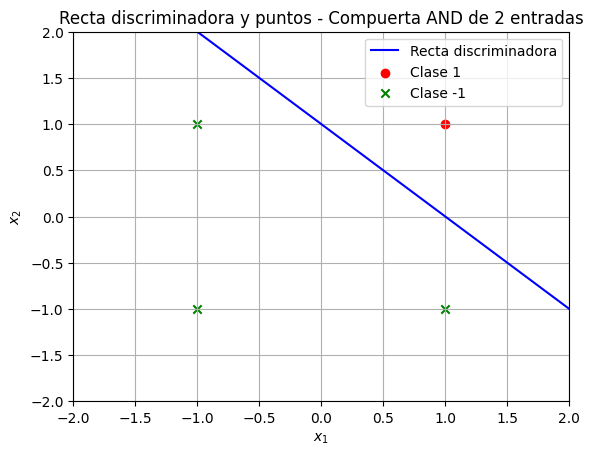

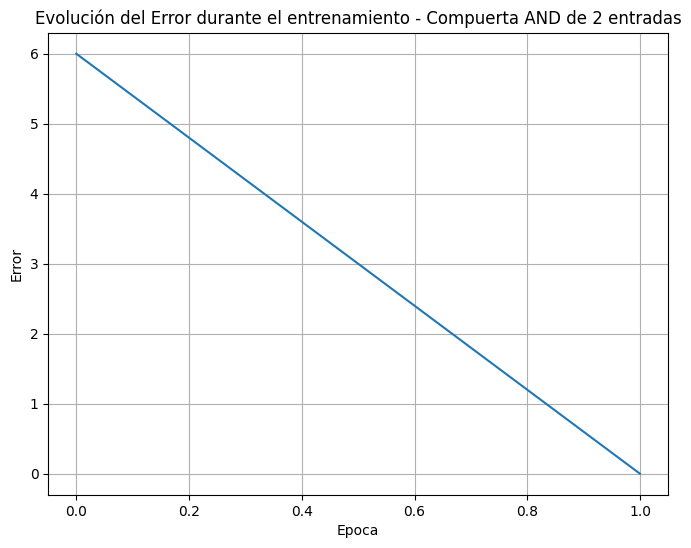

In [130]:
# Datos para la función AND
X_and = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

# Entrenar para la función AND
perceptron_and = Perceptron(2,learning_rate=0.01, epochs=10)
perceptron_and.train(X_and, y_and)
perceptron_and.plot_decision_boundary(X_and, y_and, "Compuerta AND de 2 entradas")
perceptron_and.plot_error("Compuerta AND de 2 entradas")

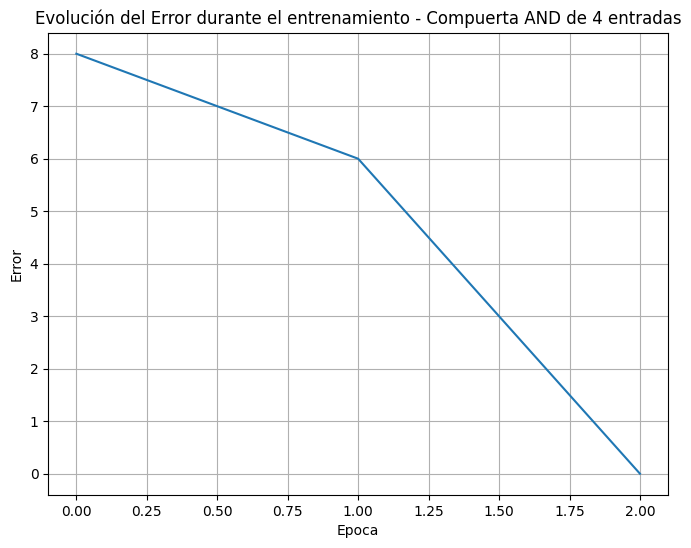

In [131]:
# Entradas para las 4 variables (-1, 1)
X_and = np.array([
    [-1, -1, -1, -1],
    [-1, -1, -1,  1],
    [-1, -1,  1, -1],
    [-1, -1,  1,  1],
    [-1,  1, -1, -1],
    [-1,  1, -1,  1],
    [-1,  1,  1, -1],
    [-1,  1,  1,  1],
    [ 1, -1, -1, -1],
    [ 1, -1, -1,  1],
    [ 1, -1,  1, -1],
    [ 1, -1,  1,  1],
    [ 1,  1, -1, -1],
    [ 1,  1, -1,  1],
    [ 1,  1,  1, -1],
    [ 1,  1,  1,  1]
])

# Salidas para la función AND
y_and = np.array([
    -1, -1, -1, -1,
    -1, -1, -1, -1,
    -1, -1, -1, -1,
    -1, -1, -1,  1  # Solo 1 si todas las entradas son 1
])

# Entrenar para la función AND
perceptron_and = Perceptron(4,learning_rate=0.01, epochs=100)
perceptron_and.train(X_and, y_and)
perceptron_and.plot_error("Compuerta AND de 4 entradas")

### Caso compuerta OR

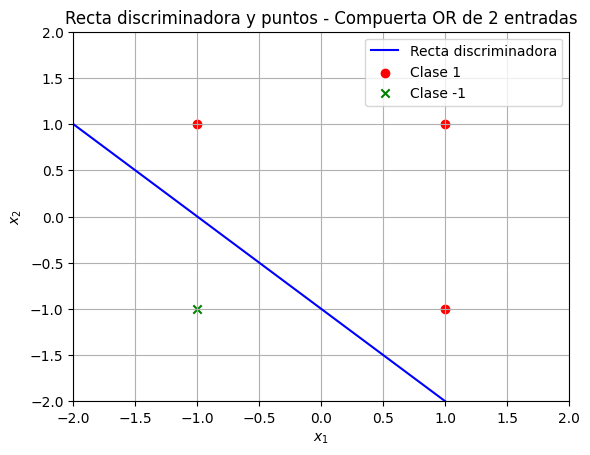

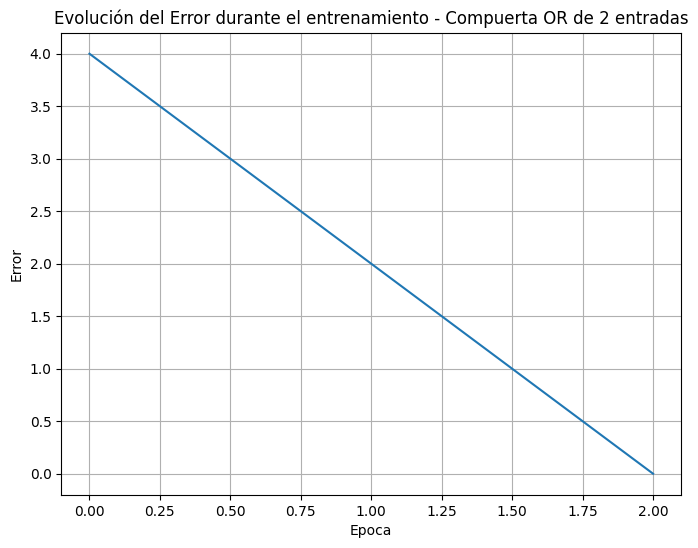

In [133]:
# Datos para la función OR
X_or = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_or = np.array([-1, 1, 1, 1])

# Entrenar para la función OR
perceptron_or = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_or.train(X_or, y_or)
perceptron_or.plot_decision_boundary(X_or, y_or, "Compuerta OR de 2 entradas")
perceptron_or.plot_error("Compuerta OR de 2 entradas")

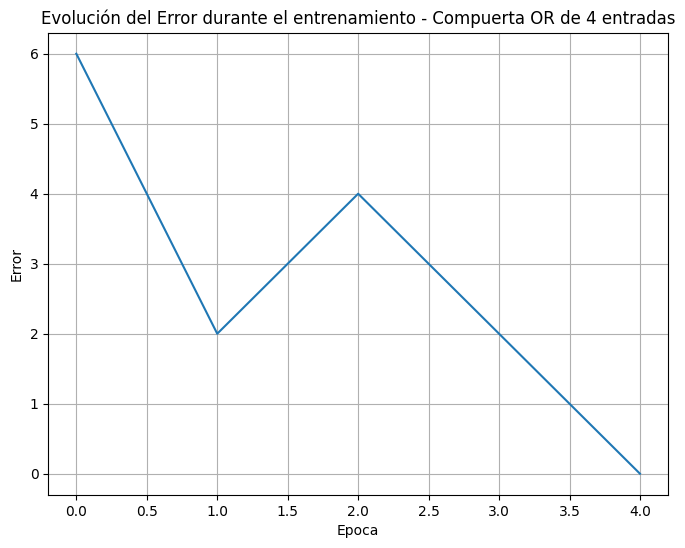

In [144]:
# Entradas para las 4 variables (-1, 1) (igual que X_and)
X_or = X_and

# Salidas para la función OR
y_or = np.array([
    -1,  1,  1,  1,
     1,  1,  1,  1,
     1,  1,  1,  1,
     1,  1,  1,  1  # 1 si al menos una entrada es 1
])

# Entrenar para la función OR
perceptron_or = Perceptron(4,learning_rate=0.01, epochs=1000)
perceptron_or.train(X_or, y_or)
perceptron_or.plot_error("Compuerta OR de 4 entradas")

-------------------------------------------------------------------------
# Ejercicio 2

Determine numéricamente cómo varía la capacidad del perceptrón simple en función
del número de patrones enseñados.

$$ N : \text{Cantidad de features o dimension del espacio de patrones} \quad \wedge \quad N_p : \text{Cantidad de patrones a enseñar}  $$


$$ C (N,N_p) = \frac{\text{\# Problemas linealmente separables}}{ \text{ \# Problemas Totales}} $$

Proceso para estimar de forma numerica la capacidad del perceptron simple en funcion del numero de patrones ensenados para N fijo:

1) Generar $N_p$ patrones: $\vec{X}_n (i) \sim \mathcal{U}(-1,1) $ y $ Y_n \sim \mathcal{B}(p=\frac{1}{2}) $
2) Entrenar el perceptron
3) Si el perceptron aprendel el problema: $N_p \longleftarrow N_p + 1 $

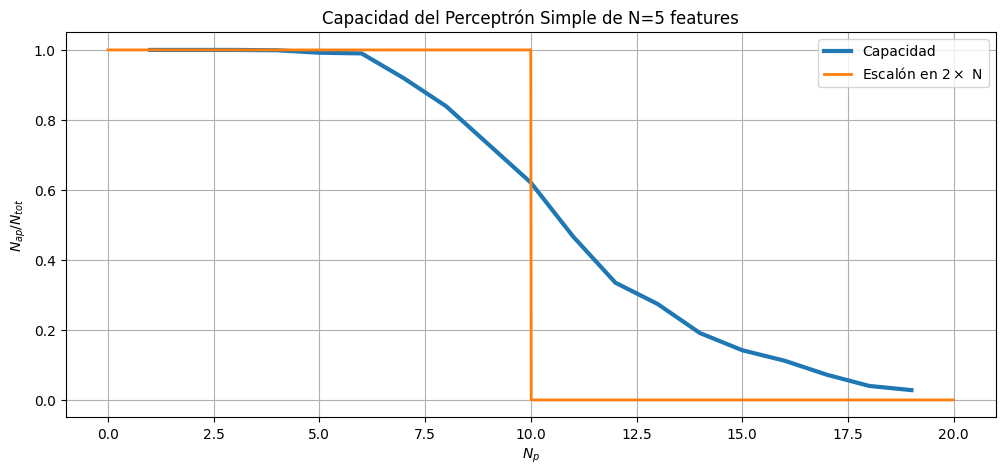

In [153]:
import numpy as np
import matplotlib.pyplot as plt


# Dimensión del espacio de patrones (número de características)
N = 5

# Vector de número de patrones (Np) a probar
Np_vec = np.arange(1, N * 4, 1)

# Inicialización del vector de capacidad
Capacidad_vec = np.zeros(Np_vec.shape)

# Iterar sobre diferentes valores de Np
for i, Np in enumerate(Np_vec):
    # Total de problemas a presentar (100 * Np)
    problemas_Np = 1000

    # Contador de problemas aprendidos correctamente
    Nap = 0

    # Generar y evaluar cada problema
    for _ in range(problemas_Np):
        # Patrones de entrada aleatorios y salidas Y en {-1, 1}
        patterns = 2 * np.random.uniform(size=(Np, N)) - 1
        Y = 2 * np.random.binomial(n=1, p=1/2, size=Np) - 1

        # Crear y entrenar el perceptrón
        perceptron = Perceptron(input_size=N, learning_rate=0.1, epochs=50)
        error = perceptron.train(patterns, Y)

        # Contar si el problema se aprendió sin error
        if error == 0:
            Nap += 1

    # Calcular la capacidad de aprendizaje
    Capacidad_vec[i] = Nap / problemas_Np

# Graficar los resultados obtenidos para N=dim
plt.figure(figsize=(12, 5))

# Capacidad estimada del perceptrón
plt.plot(Np_vec, Capacidad_vec, linewidth=3, label='Capacidad')

# Escalón negativo centrado en 2*dim
x = np.arange(0, 4 * N, 0.01)
y = x <= 2 * N
plt.plot(x, y, linewidth=2, label='Escalón en $2 \\times$ N')

# Configuración del gráfico
plt.title('Capacidad del Perceptrón Simple de N={} features'.format(N))
plt.xlabel('$N_p$')
plt.ylabel('$N_{ap}/N_{tot}$')
plt.legend()
plt.grid()
plt.show()


-------------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 3

Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4
entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre
cómo evoluciona el error durante el entrenamiento.


### Representacion Matricial de la Red (XOR: 2 entradas)
Muestro como se realizaran las cuentas matriciales para un perceptron multicapa de 2 entradas + sesgo, 3 neuronas en capa oculta y 1 neurona de salida


#### Capa de Entrada
La capa de entrada tendra 2 entradas y como se entrenara con 4 patrones, la matriz de entrada sera de $\textbf{3x4}$, la primera fila son 1s que representaran el sesgo, siendo asi la matriz de entrada $\textbf{X}$ :
$$ X =  
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
$$
Cada columna es un patrón y cada fila es la entrada a cada entrada de la capa de entrada.


#### Capa Oculta
Para el caso de la XOR de 2 entradas, el caso minimo con el que se logra aprenderla es con 3 neuronas de capa oculta. Supongamos 3 neuronas de capa oculta (filas), entonces la matriz de
pesos sinapticos entre la capa de entrada y la capa oculta es $W_{input} \in \mathbb{R}^{3 \times 2}$
$$
W_{input} =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
$$
Donde $w_{j0}$ corresponde al peso sinaptico del sesgo de la neurona j


#### Capa Salida
Dado que se tiene una sola salida y la capa oculta solo tiene 3 neuronas, la matriz de pesos sinapticos entre la capa oculta y la capa de salida es $W_{output} \in \mathbb{R}^{1 \times 3}$ :
$$
W_{output} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
$$



### Fordward Propagation
Partimos desde la capa de entrada, obtengo que la entrada neta a la capa oculta es:

$$
H_{input} = W_{input} * X =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
*
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} & h_{14} \\
h_{21} & h_{22} & h_{23} & h_{24} \\
h_{31} & h_{32} & h_{33} & h_{34}
\end{bmatrix}

$$

Luego, pasando por la funcion de activación $\textbf{g(x)}$ obtengo que:
$$X_{input} = g(H_{input}) = \begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}$$

Luego se parte de la entrada neta a la capa de salida :
$$
H_{output} = W_{output} * X_{input} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
*
\begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}
=
\begin{bmatrix}
h_{1} & h_{2} & h_{3} & h_{4} \\
\end{bmatrix}
$$


Finalmente la salida $y$ es:
$$
y = g(H_{output}) = \begin{bmatrix}
y_{1} & y_{2} & y_{3} & y_{4} \\
\end{bmatrix}
$$

### Backward Propagation
El primer delta a calcular es :
$$
\begin{align*}
\delta_{output} = g'(H_{output}) \cdot (y_d - y) & = \begin{bmatrix}
g'(h_{1}) & g'(h_{2}) & g'(h_{3}) & g'(h_{4}) \\
\end{bmatrix}
\cdot
\begin{bmatrix}
y_d(1) - y_{1} & y_d(2) - y_{2} & y_d(3) - y_{3} & y_d(4) - y_{4} \\
\end{bmatrix} \\
& =
\begin{bmatrix}
g'(h_{1})(y_d(1) - y_{1}) & g'(h_{2})(y_d(2) - y_{2}) & g'(h_{3})(y_d(3) - y_{3}) & g'(h_{4})(y_d(4) - y_{4}) \\
\end{bmatrix}
\end{align*}
$$

Luego:
$$
\delta_{hidden} = g'(H_{input}) \cdot (W_{output} * \delta_{output}^T)
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Clase para una capa de la red neuronal
class Layer:
    def __init__(self, input_size, output_size, activation_function, activation_derivative):
        # Inicialización de pesos y sesgos
        self.weights = np.random.randn(input_size, output_size) * 0.1
        self.biases = np.zeros((1, output_size))
        self.activation_function = activation_function
        self.activation_derivative = activation_derivative

    def forward(self, x):
        # Propagación hacia adelante
        self.input_data = x
        self.h = np.dot(x, self.weights) + self.biases
        self.output = self.activation_function(self.h)
        return self.output

    def backward(self, output_error, learning_rate):
        # Retropropagación del error
        delta = output_error * self.activation_derivative(self.h)
        input_error = np.dot(delta, self.weights.T)

        # Actualización de los pesos y sesgos
        self.weights -= learning_rate * np.dot(self.input_data.T, delta)
        self.biases -= learning_rate * np.sum(delta, axis=0, keepdims=True)

        return input_error

# Funciones de activación (tangente hiperbólica)
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# Agrega una función de activación lineal
def linear(x):
    return x

def linear_derivative(x):
    # La derivada de una función lineal es 1
    return np.ones_like(x)


# Clase para el perceptrón multicapa
class MultilayerPerceptron:
    def __init__(self, layer_sizes, activation_function, activation_derivative, learning_rate=0.1, isLinearOut = False):
        self.errors_train = []
        self.errors_test = []
        self.errors = []
        self.layers = []
        self.learning_rate = learning_rate
        for i in range(len(layer_sizes) - 1):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i + 1], activation_function, activation_derivative))
        # Cambia la función de activación de la última capa a lineal
        if(isLinearOut) :
            self.layers[-1].activation_function = linear
            self.layers[-1].activation_derivative = linear_derivative


    def forward(self, X):
        # Propagación hacia adelante a través de todas las capas
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, X, y):
        # Cálculo del error y retropropagación
        output_error = self.layers[-1].output - y
        for layer in reversed(self.layers):
            output_error = layer.backward(output_error, self.learning_rate)

    def train(self, X, y, epochs):
        # Entrenamiento con actualización en batch
        for _ in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calcular el error
            error = np.mean(np.square(output - y))  # Error cuadrático medio
            self.errors.append(error)

            # Backward pass
            self.backward(X, y)


    def plot_error_xor(self):
        # Mostrar evolución del error
        plt.plot(self.errors)
        plt.xlabel('Epoch')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el Entrenamiento')
        plt.show()

    def evaluate(self, X, y):
        # Evaluar el rendimiento de la red
        output = self.forward(X)
        for i in range(len(y)):
            print(f"Resultado de la red neuronal: {output[i]} y resultado: {y[i]}")

    def train_minibatch(self, X_train, y_train, X_test, y_test, epochs, batch_size=1):
        n_samples = X_train.shape[0]
        for epoch in range(epochs):
            # Embarajar los datos de entrenamiento
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_train = X_train[indices]
            y_train = y_train[indices]

            for start_idx in range(0, n_samples, batch_size):
                end_idx = start_idx + batch_size
                X_batch = X_train[start_idx:end_idx]
                y_batch = y_train[start_idx:end_idx]

                # Forward pass y retropropagación por minibatch
                output = self.forward(X_batch)
                batch_error = np.mean(np.square(output - y_batch))
                self.errors_train.append(batch_error)
                self.backward(X_batch, y_batch)

            # Calcular error en el set de testeo al final de cada época
            test_output = self.forward(X_test)
            epoch_test_error = np.mean(np.square(test_output - y_test))
            self.errors_test.append(epoch_test_error)

    def plot_errors_function(self):
        # Gráfico de error de entrenamiento por minibatch
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.errors_train, label='Error de entrenamiento por minibatch')
        plt.xlabel('Iteración (minibatch)')
        plt.ylabel('Error')
        plt.title('Error de Entrenamiento por Minibatch')

        # Gráfico de error de testeo por época
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 2)
        plt.plot(self.errors_test, label='Error de testeo por época', color='orange')
        plt.xlabel('Época')
        plt.ylabel('Error')
        plt.title('Error de Testeo por Época')

        plt.tight_layout()
        plt.show()

    def plot_scatter(self, X, y):
        output = self.forward(X)
        plt.scatter(y, output, color='blue', alpha=0.5)
        plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')  # Línea de referencia ideal
        plt.xlabel('Salida deseada')
        plt.ylabel('Salida obtenida')
        plt.title('Gráfico de dispersión entre la salida deseada y obtenida')
        plt.show()


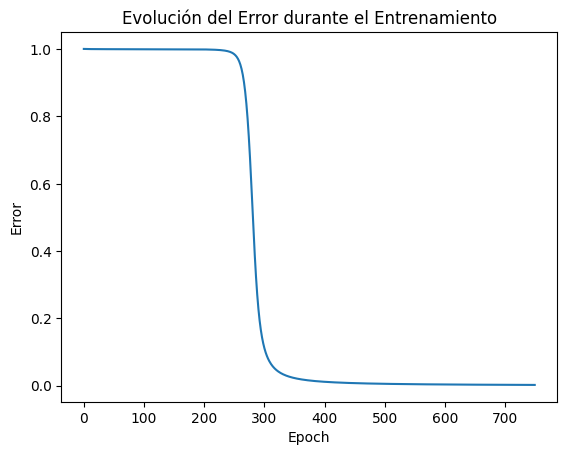


Evaluación del modelo para XOR de 2 entradas:
Resultado de la red neuronal: [-0.95796088] y resultado: [-1]
Resultado de la red neuronal: [0.94444486] y resultado: [1]
Resultado de la red neuronal: [0.94701632] y resultado: [1]
Resultado de la red neuronal: [-0.95758527] y resultado: [-1]


In [95]:
# Datos para XOR de 2 entradas con -1 y 1
X_xor2 = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_xor2 = np.array([[-1], [1], [1], [-1]])

# Crear el modelo para XOR de 2 entradas
mlp_2 = MultilayerPerceptron([2, 3, 1],tanh,tanh_derivative, learning_rate=0.1)
mlp_2.train(X_xor2, y_xor2, epochs=750)
mlp_2.plot_error_xor()

# Evaluación final
print("\nEvaluación del modelo para XOR de 2 entradas:")
mlp_2.evaluate(X_xor2, y_xor2)

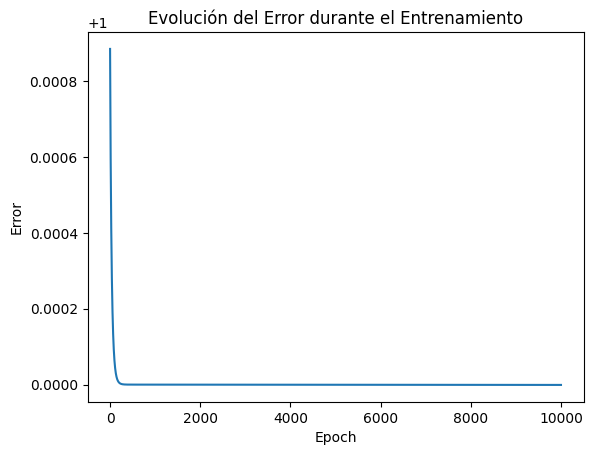


Evaluación del modelo para XOR de 4 entradas:
Resultado de la red neuronal: [8.68445166e-05] y resultado: [-1]
Resultado de la red neuronal: [-0.00025733] y resultado: [1]
Resultado de la red neuronal: [5.77958644e-05] y resultado: [1]
Resultado de la red neuronal: [0.00010509] y resultado: [-1]
Resultado de la red neuronal: [5.24474265e-05] y resultado: [1]
Resultado de la red neuronal: [0.00013571] y resultado: [-1]
Resultado de la red neuronal: [-0.00018446] y resultado: [-1]
Resultado de la red neuronal: [4.50944102e-05] y resultado: [1]
Resultado de la red neuronal: [-1.50932472e-05] y resultado: [1]
Resultado de la red neuronal: [0.00022192] y resultado: [-1]
Resultado de la red neuronal: [-0.00011938] y resultado: [-1]
Resultado de la red neuronal: [3.04370475e-05] y resultado: [1]
Resultado de la red neuronal: [-9.93843524e-05] y resultado: [-1]
Resultado de la red neuronal: [8.6655015e-06] y resultado: [1]
Resultado de la red neuronal: [9.84516039e-05] y resultado: [1]
Result

In [111]:
# Datos para XOR de 4 entradas con -1 y 1
X_xor4 = np.array([[-1, -1, -1, -1], [-1, -1, -1, 1], [-1, -1, 1, -1], [-1, -1, 1, 1],
                [-1, 1, -1, -1], [-1, 1, -1, 1], [-1, 1, 1, -1], [-1, 1, 1, 1],
                [1, -1, -1, -1], [1, -1, -1, 1], [1, -1, 1, -1], [1, -1, 1, 1],
                [1, 1, -1, -1], [1, 1, -1, 1], [1, 1, 1, -1], [1, 1, 1, 1]])
y_xor4 = np.array([[-1], [1], [1], [-1], [1], [-1], [-1], [1],
                [1], [-1], [-1], [1], [-1], [1], [1], [-1]])


# Crear el modelo para XOR de 4 entradas
mlp_4 = MultilayerPerceptron([4, 6, 1],tanh,tanh_derivative, learning_rate=0.01)
mlp_4.train(X_xor4, y_xor4, epochs=10000)
mlp_4.plot_error_xor()

# Evaluación final
print("\nEvaluación del modelo para XOR de 4 entradas:")
mlp_4.evaluate(X_xor4, y_xor4)

-------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 4

a) Implemente una red con aprendizaje Backpropagation que aprenda la siguiente
función:
f ( x , y ,z)=sin( x )+cos( y )+z
donde: x e y ∊ [ 0 ,2 π ] y z ∊[−1,1]. Para ello construya un conjunto de datos de
entrenamiento y un conjunto de evaluación. Muestre la evolución del error de
entrenamiento y de evaluación en función de las épocas de entrenamiento.

b) Estudie la evolución de los errores durante el entrenamiento de una red con una
capa oculta de 30 neuronas cuando el conjunto de entrenamiento contiene 40
muestras. ¿Que ocurre si el minibatch tiene tamaño 40? ¿Y si tiene tamaño 1?



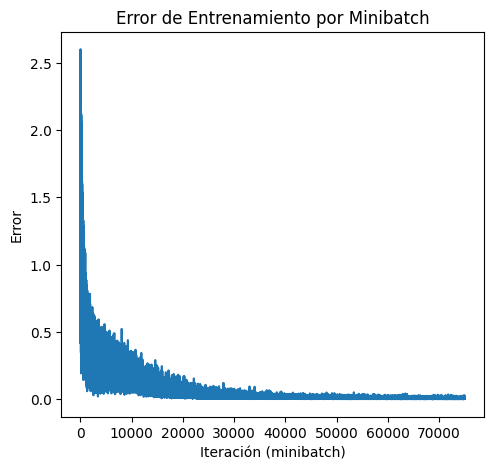

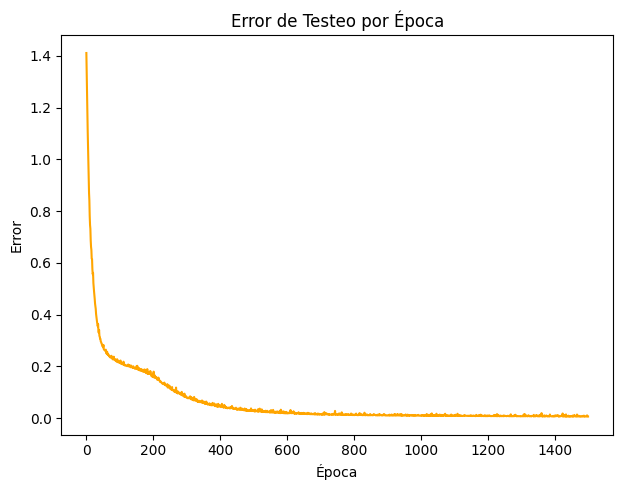

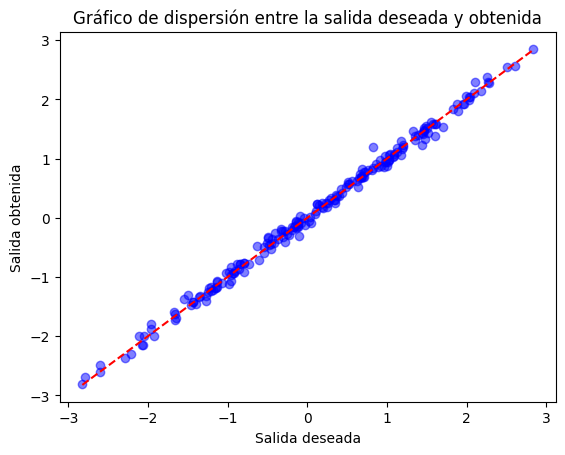

In [43]:

# Generar datos de entrenamiento y evaluación
def generate_data(n_samples):
    x = np.random.uniform(0, 2 * np.pi, n_samples)
    y = np.random.uniform(0, 2 * np.pi, n_samples)
    z = np.random.uniform(-1, 1, n_samples)
    f = np.sin(x) + np.cos(y) + z
    return np.column_stack((x, y, z)), f.reshape(-1, 1)

# Inicializar y entrenar la red
X_train, y_train = generate_data(500)
X_test, y_test = generate_data(200)

# En la inicialización de la red, especifica la función lineal para la última capa
mlp = MultilayerPerceptron(
    layer_sizes=[3, 30, 1],
    activation_function=tanh,
    activation_derivative=tanh_derivative,
    learning_rate=0.0007,
    isLinearOut= True
)

# Entrenamiento con minibatch de 1 (SGD)
mlp.train_minibatch(X_train, y_train, X_test, y_test, epochs=1500, batch_size=10)
mlp.plot_errors_function()

# Evaluar y graficar la salida obtenida vs. salida deseada en el testeo
mlp.plot_scatter(X_test, y_test)



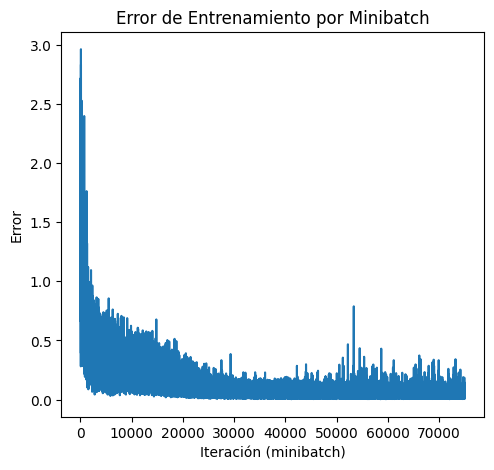

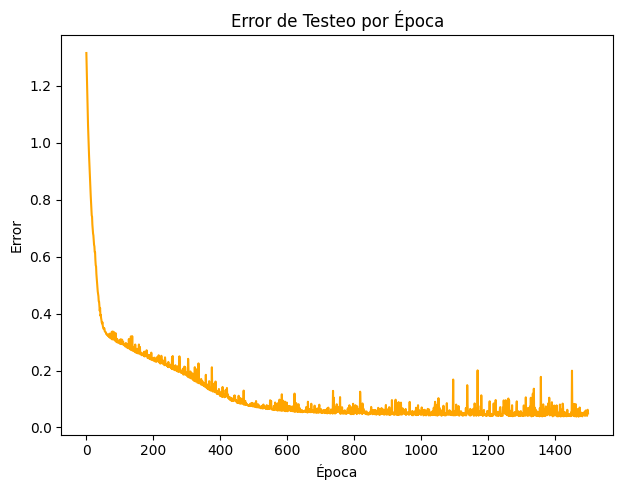

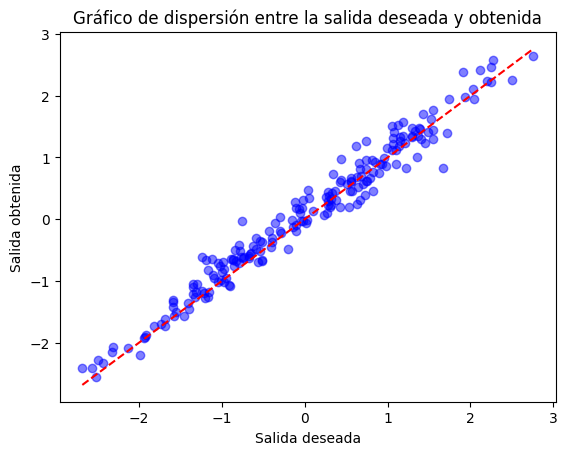

In [64]:
# Inicializar y entrenar la red
X_train, y_train = generate_data(500)
X_test, y_test = generate_data(200)

# En la inicialización de la red, especifica la función lineal para la última capa
mlp = MultilayerPerceptron(
    layer_sizes=[3, 5, 1],
    activation_function=tanh,
    activation_derivative=tanh_derivative,
    learning_rate=0.0007,
    isLinearOut= True
)

# Entrenamiento con minibatch de 1 (SGD)
mlp.train_minibatch(X_train, y_train, X_test, y_test, epochs=1500, batch_size=10)
mlp.plot_errors_function()

# Evaluar y graficar la salida obtenida vs. salida deseada en el testeo
mlp.plot_scatter(X_test, y_test)

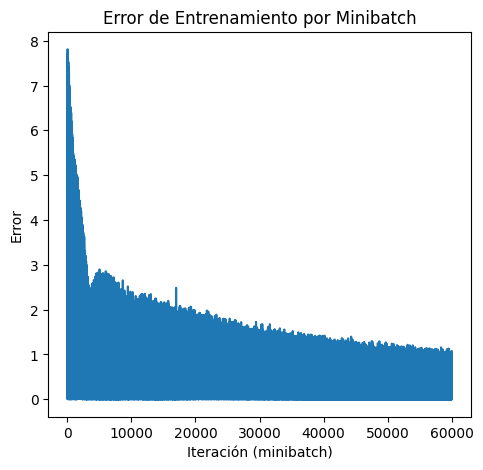

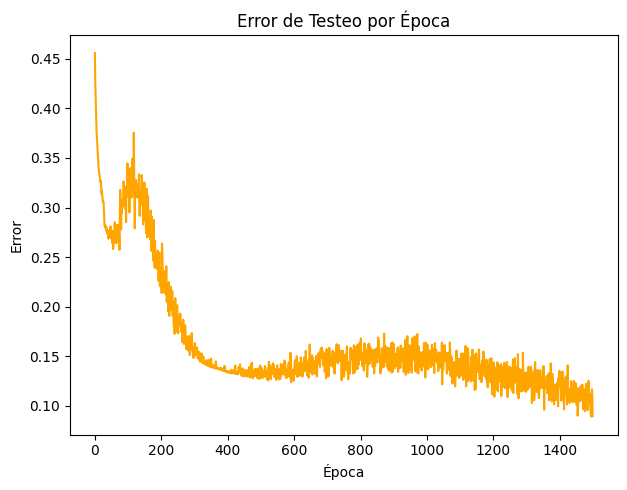

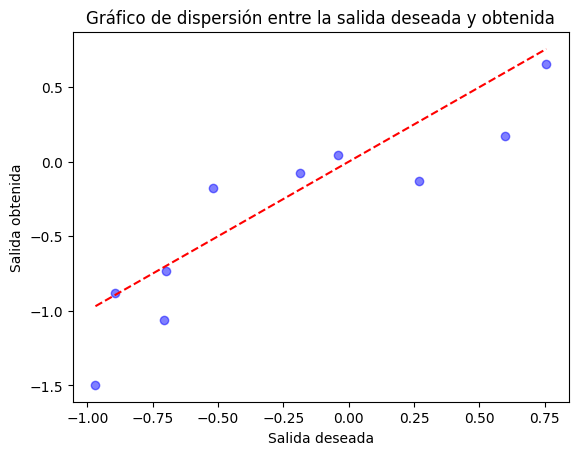

In [104]:
# Inicializar y entrenar la red
X_train, y_train = generate_data(40)
X_test, y_test = generate_data(10)

# En la inicialización de la red, especifica la función lineal para la última capa
mlp = MultilayerPerceptron(
    layer_sizes=[3, 30, 1],
    activation_function=tanh,
    activation_derivative=tanh_derivative,
    learning_rate=0.001,
    isLinearOut= True
)

# Entrenamiento con minibatch de 1 (SGD)
mlp.train_minibatch(X_train, y_train, X_test, y_test, epochs=1500, batch_size=1)
mlp.plot_errors_function()

# Evaluar y graficar la salida obtenida vs. salida deseada en el testeo
mlp.plot_scatter(X_test, y_test)

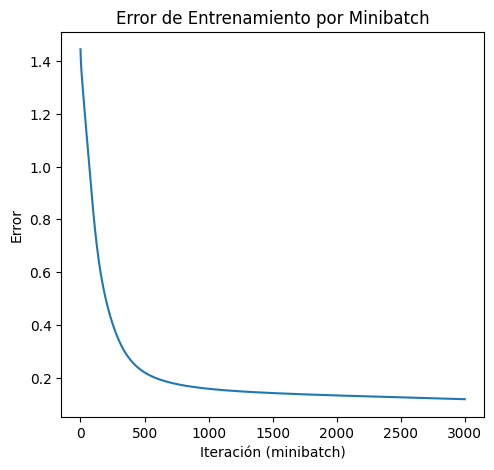

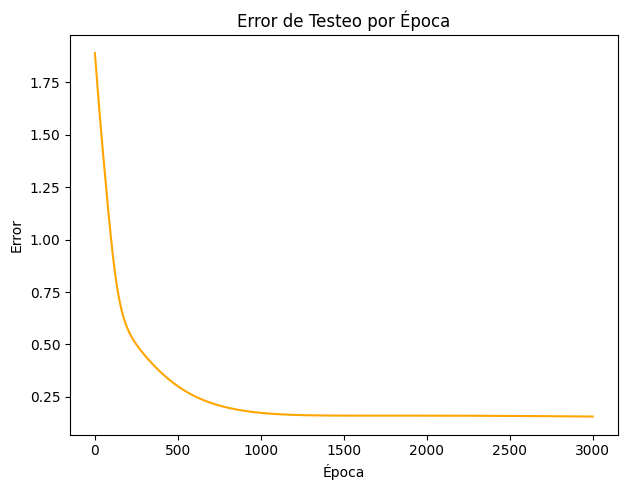

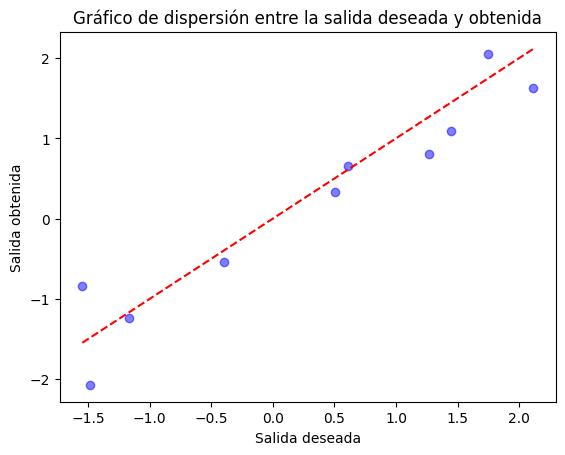

In [79]:
# Inicializar y entrenar la red
X_train, y_train = generate_data(40)
X_test, y_test = generate_data(10)

# En la inicialización de la red, especifica la función lineal para la última capa
mlp = MultilayerPerceptron(
    layer_sizes=[3, 30, 1],
    activation_function=tanh,
    activation_derivative=tanh_derivative,
    learning_rate=0.0007,
    isLinearOut= True
)

# Entrenamiento con minibatch de 1 (SGD)
mlp.train_minibatch(X_train, y_train, X_test, y_test, epochs=3000, batch_size=40)
mlp.plot_errors_function()

# Evaluar y graficar la salida obtenida vs. salida deseada en el testeo
mlp.plot_scatter(X_test, y_test)

---------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 5
Siguiendo el trabajo de Hinton y Salakhutdinov (2006), entrene una máquina restringida
de Boltzmann con imágenes de la base de datos MNIST. Muestre el error de
recontruccion durante el entrenamiento, y ejemplos de cada uno de los dígitos
reconstruidos.

$$
\begin{align*}
1) \ & m_i = \text{pixel}(i) \\
2) \ & v_i \sim \mathcal{N}(\mu = m_i, \sigma = 1) \\
3) \ & h_j = 1 \text{ con probabilidad } p = \sigma \left( \sum_i w_{ij} v_i + b_j \right) \text{ con } \sigma(x) = \frac{1}{1 + e^{-x}} \\
4) \ & \text{Guardo } (v_i, h_j) \text{ en set DATA} \\
5) \ & m_i = \sum_i w_{ij} h_j + b_i \\
6) \ & v_i \sim \mathcal{N}(\mu = m_i, \sigma = 1) \\
7) \ & h_j = 1 \text{ con probabilidad } p = \sigma \left( \sum_i w_{ij} v_i + b_j \right) \text{ con } \sigma(x) = \frac{1}{1 + e^{-x}} \\
8) \ & \text{Guardo } (v_i, h_j) \text{ en set RECON}
\end{align*}
$$

Repito así para todas las imágenes del set o entreno en minibatch.

Luego:

$$
\begin{align*}
\Delta w_{ij} &= \eta \left( \langle (v_i \cdot h_j) \rangle_{\text{DATA}}^M - \langle (v_i \cdot h_j) \rangle_{\text{RECON}}^M \right) \\
\Delta b_i &= \eta \left( \langle (v_i) \rangle_{\text{DATA}}^M - \langle (v_i) \rangle_{\text{RECON}}^M \right) \\
\Delta b_j &= \eta \left( \langle (h_j) \rangle_{\text{DATA}}^M - \langle (h_j) \rangle_{\text{RECON}}^M \right)
\end{align*}
$$



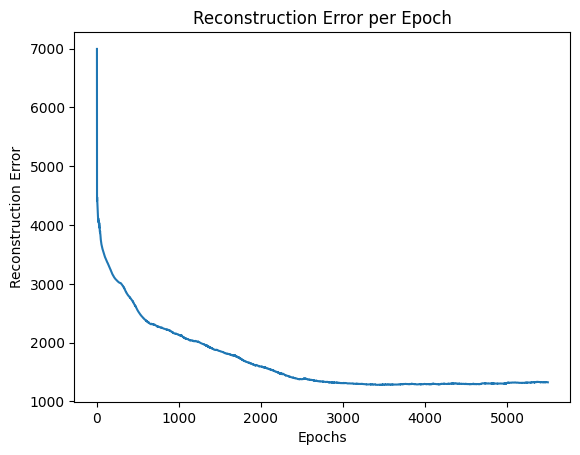

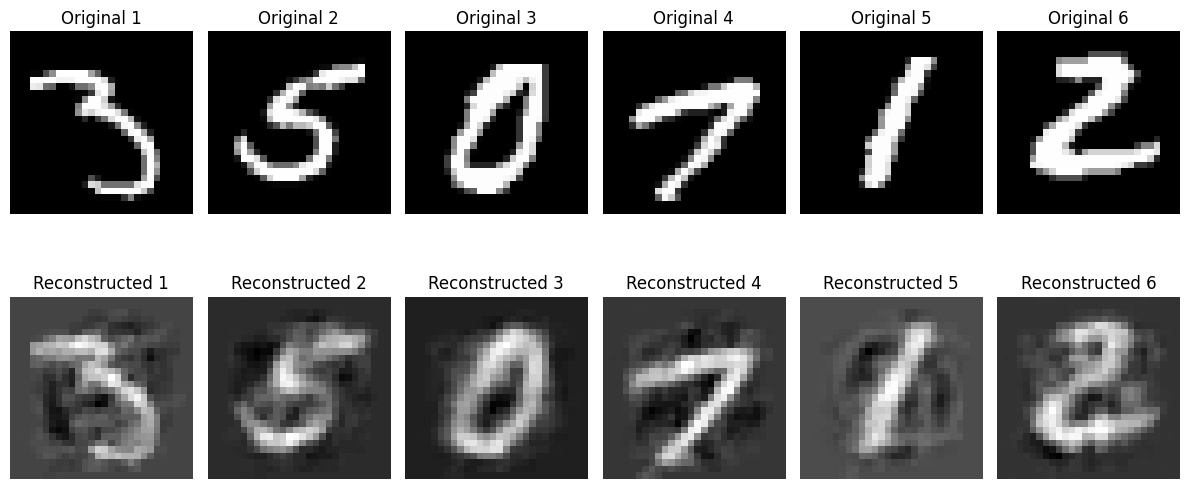

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate

        self.weights = np.random.normal(0, 1, (self.n_visible, self.n_hidden))

        self.bias_visible = np.zeros(n_visible)
        self.bias_hidden = np.zeros(n_hidden)

    def sigmoid(self, x):
        return (1/(1 + np.exp(-np.clip(x,-500,500))))

    def forward(self, visible_state):
        # Cálculo de activación de la capa oculta
        hidden_activation = np.dot(visible_state, self.weights) + self.bias_hidden
        hidden_prob = self.sigmoid(hidden_activation)
        hidden_state = np.random.binomial(n=1, p= hidden_prob)
        return hidden_state

    def backward(self, h):
        # Reconstrucción de la capa visible
        m_i = np.dot(h, self.weights.T) + self.bias_visible
        visible_state = np.random.normal(loc=m_i, scale=1, size=m_i.shape)
        hidden_prob = self.sigmoid(np.dot(visible_state, self.weights) + self.bias_hidden)
        hidden_state= np.random.binomial(n=1, p= hidden_prob)
        return visible_state, hidden_state, m_i


    def update_weights_and_biases(self, v_o, h_o, v_k, h_k):
        # Producto externo de las filas de visible_state con hidden_state
        positive_grad = np.dot(v_o.T, h_o)

        # Producto externo de las filas de visible_reconstructed con hidden_reconstructed
        negative_grad = np.dot(v_k.T, h_k)

        # Actualización de los pesos
        self.weights += self.learning_rate * (positive_grad - negative_grad) / v_o.shape[0]

        # Actualización de los sesgos
        self.bias_visible += self.learning_rate * np.mean(v_o - v_k, axis=0)
        self.bias_hidden += self.learning_rate * np.mean(h_o - h_k, axis=0)


    def train(self, train_data, epochs=10):
        errors = []  # Lista para almacenar los errores de cada época
        for _ in range(epochs):
            error = 0  # Para calcular el error total de cada época
            # Asegúrate de que data esté en un formato adecuado (ej., normalizado entre 0 y 1)
            visible_state = np.random.normal(loc=train_data, scale=1, size=train_data.shape)
            hidden_state = self.forward(visible_state)
            visible_reconstructed, hidden_reconstructed, _ = self.backward(hidden_state)
            self.update_weights_and_biases(visible_state, hidden_state, visible_reconstructed, hidden_reconstructed)

            # Calcular el error de reconstrucción (error cuadrático medio)
            error = np.mean(np.square(train_data - visible_reconstructed))  # Error cuadrático medio
            
            # Guardar el error promedio de esta época
            errors.append(error)

            # Mostrar el error de reconstrucción al final de cada época
            #print(f"Epoch {epoch+1}/{epochs}, Reconstruction Error: {total_error / len(train_data)}")

        # Graficar el error de reconstrucción
        plt.plot(range(epochs), errors)
        plt.xlabel('Epochs')
        plt.ylabel('Reconstruction Error')
        plt.title('Reconstruction Error per Epoch')
        plt.show()


# Graficar 3 imágenes aleatorias de las originales y 3 de las reconstruidas
def plot_random_images(original_images, reconstructed_images, n_images=6):
    # Seleccionar 3 índices aleatorios
    random_indices = random.sample(range(original_images.shape[0]), n_images)

    plt.figure(figsize=(12, 6))

    # Graficar las imágenes originales
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, i)
        plt.imshow(original_images[idx].reshape(28, 28), cmap='gray')  # Asumo que las imágenes son 28x28
        plt.title(f'Original {i}')
        plt.axis('off')

    # Graficar las imágenes reconstruidas
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, n_images + i)
        plt.imshow(reconstructed_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Reconstructed {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Cargar el archivo .mat
mat_file_path = 'datosTrain.mat'
mat_data = scipy.io.loadmat(mat_file_path)

# Asignar los datos de entrenamiento y prueba desde el archivo .mat
train_images = mat_data['data']

# Crear la RBM y entrenar
rbm_network = RBM(n_visible=784, n_hidden=70, learning_rate=0.035)  # Ajusta el número de neuronas ocultas según sea necesario
rbm_network.train(train_images, epochs=5500)

# Obtener las imágenes reconstruidas
hidden_state = rbm_network.forward(train_images)
_, _, reconstructed_images = rbm_network.backward(hidden_state)


# Llamar a la función para graficar
plot_random_images(train_images, reconstructed_images)


--------------------------------------------------------------------------------
# Ejercicio 6


Epoch 1/7, Loss: 0.26733580231666565
Epoch 2/7, Loss: 0.4000919759273529
Epoch 3/7, Loss: 0.37997967004776
Epoch 4/7, Loss: 0.3958126902580261
Epoch 5/7, Loss: 0.3908347189426422
Epoch 6/7, Loss: 0.3439606726169586
Epoch 7/7, Loss: 0.30956026911735535
Precisión en el conjunto de prueba: 92.78%


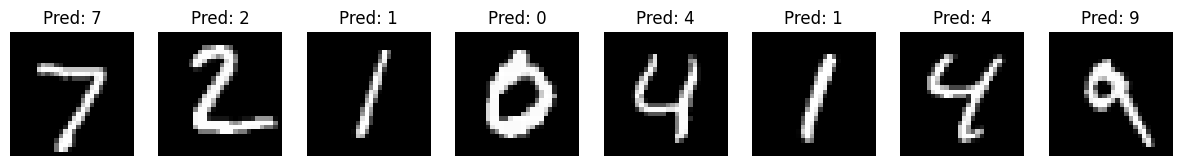

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Definición de la CNN mínima
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=2, out_channels=3, kernel_size=7)
        self.fc1 = nn.Linear(12, 10)  # Cambiamos las neuronas de entrada a 12 después del pooling adicional.

    def forward(self, x):
        # Primera capa convolucional + activación ReLU + MaxPooling
        x = self.pool(F.relu(self.conv1(x)))
        
        # Segunda capa convolucional + activación ReLU + MaxPooling
        x = self.pool(F.relu(self.conv2(x)))
        
        # Tercer MaxPooling
        x = self.pool(x)
        
        # Aplanar las dimensiones para la capa completamente conectada
        x = torch.flatten(x, 1)
        
        # Capa completamente conectada
        x = self.fc1(x)
        
        return x
    

# Hiperparámetros
batch_size = 32
learning_rate = 0.01
n_epochs = 7

# Datos (usa tus archivos .pt del MNIST proporcionados por el profe)
training_data = torch.load('MNIST_training_data.pt',weights_only=False).to(torch.float32)
training_labels = torch.load('MNIST_training_labels.pt',weights_only=False)
test_data = torch.load('MNIST_test_data.pt',weights_only=False).to(torch.float32)
test_labels = torch.load('MNIST_test_labels.pt', weights_only=False)

# Normalizar y redimensionar los datos
training_data = training_data / 255.0  # Normalizar entre 0 y 1
test_data = test_data / 255.0
training_data = training_data.unsqueeze(1)  # Agregar dimensión de canal
test_data = test_data.unsqueeze(1)

# Modelo, pérdida y optimizador
model = SimpleCNN().to('cpu')  # Cambiar a 'cuda' si tienes GPU disponible
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Entrenamiento
for epoch in range(n_epochs):
    model.train()
    for i in range(0, len(training_data), batch_size):
        x_batch = training_data[i:i+batch_size]
        y_batch = training_labels[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

# Evaluación
model.eval()
correct = 0
total = 0
fig, axes = plt.subplots(1, 8, figsize=(15, 5))  # Gráfico para mostrar 5 imágene
with torch.no_grad():
    for i in range(0, len(test_data), batch_size):
        x_batch = test_data[i:i+batch_size]
        y_batch = test_labels[i:i+batch_size]

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Visualizar 5 imágenes y sus salidas
        if i == 0:  # Mostrar solo las primeras 5 imágenes del primer batch
            for j in range(8):
                ax = axes[j]
                ax.imshow(x_batch[j].squeeze(), cmap='gray')
                ax.set_title(f'Pred: {predicted[j].item()}')
                ax.axis('off')

print(f"Precisión en el conjunto de prueba: {100 * correct / total:.2f}%")
plt.show()

Epoch 1/7, Loss: 0.3756929636001587
Epoch 2/7, Loss: 0.275551438331604
Epoch 3/7, Loss: 0.3192579448223114
Epoch 4/7, Loss: 0.32357004284858704
Epoch 5/7, Loss: 0.2977617383003235
Epoch 6/7, Loss: 0.34175387024879456
Epoch 7/7, Loss: 0.22264939546585083
Precisión en el conjunto de prueba: 92.73%


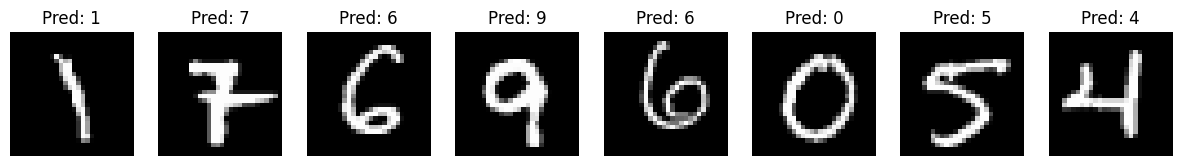

In [25]:
# Hiperparámetros
batch_size = 32
learning_rate = 0.01
n_epochs = 7

# Datos (usa tus archivos .pt del MNIST proporcionados por el profe)
training_data = torch.load('MNIST_training_data.pt',weights_only=False).to(torch.float32)
training_labels = torch.load('MNIST_training_labels.pt',weights_only=False)
test_data = torch.load('MNIST_test_data.pt',weights_only=False).to(torch.float32)
test_labels = torch.load('MNIST_test_labels.pt', weights_only=False)

# Normalizar y redimensionar los datos
training_data = training_data / 255.0  # Normalizar entre 0 y 1
test_data = test_data / 255.0
training_data = training_data.unsqueeze(1)  # Agregar dimensión de canal
test_data = test_data.unsqueeze(1)

# Modelo, pérdida y optimizador
model = SimpleCNN().to('cpu')  # Cambiar a 'cuda' si tienes GPU disponible
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Entrenamiento
for epoch in range(n_epochs):
    model.train()
    for i in range(0, len(training_data), batch_size):
        x_batch = training_data[i:i+batch_size]
        y_batch = training_labels[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

# Evaluación
model.eval()
correct = 0
total = 0
fig, axes = plt.subplots(1, 8, figsize=(15, 5))  # Gráfico para mostrar 5 imágene
with torch.no_grad():
    for i in range(0, len(test_data), batch_size):
        x_batch = test_data[i:i+batch_size]
        y_batch = test_labels[i:i+batch_size]

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Visualizar 5 imágenes y sus salidas
        if i == 96:  # Mostrar solo las primeras 5 imágenes del primer batch
            for j in range(8):
                ax = axes[j]
                ax.imshow(x_batch[j].squeeze(), cmap='gray')
                ax.set_title(f'Pred: {predicted[j].item()}')
                ax.axis('off')

print(f"Precisión en el conjunto de prueba: {100 * correct / total:.2f}%")
plt.show()

Epoch 1/15, Loss: 0.13365857303142548
Epoch 2/15, Loss: 0.10797203332185745
Epoch 3/15, Loss: 0.10044975578784943
Epoch 4/15, Loss: 0.0972326248884201
Epoch 5/15, Loss: 0.0956089049577713
Epoch 6/15, Loss: 0.0946662649512291
Epoch 7/15, Loss: 0.09402509778738022
Epoch 8/15, Loss: 0.09351379424333572
Epoch 9/15, Loss: 0.09305398166179657
Epoch 10/15, Loss: 0.09260974079370499
Epoch 11/15, Loss: 0.09216555953025818
Epoch 12/15, Loss: 0.09171610325574875
Epoch 13/15, Loss: 0.09126084297895432
Epoch 14/15, Loss: 0.0908019095659256
Epoch 15/15, Loss: 0.09034210443496704
Precisión en el conjunto de prueba: 92.44%


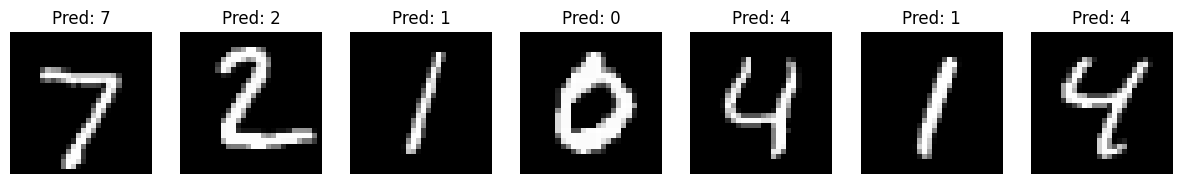

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 10)  # Capa oculta con 64 neuronas

    def forward(self, x):
        x = torch.flatten(x, 1)         # Aplanar las imágenes
        x = self.fc1(x)

        return x
# Hiperparámetros
batch_size = 32
learning_rate = 0.001
n_epochs = 15

# Modelo, pérdida y optimizador
model = SimpleMLP().to('cpu')
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Entrenamiento
for epoch in range(n_epochs):
    model.train()
    for i in range(0, len(training_data), batch_size):
        x_batch = training_data[i:i+batch_size]
        y_batch = training_labels[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

# Evaluación
model.eval()
correct = 0
total = 0
fig, axes = plt.subplots(1, 7, figsize=(15, 5))  # Gráfico para mostrar 5 imágene
with torch.no_grad():
    for i in range(0, len(test_data), batch_size):
        x_batch = test_data[i:i+batch_size]
        y_batch = test_labels[i:i+batch_size]

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Visualizar 5 imágenes y sus salidas
        if i == 0:  # Mostrar solo las primeras 5 imágenes del primer batch
            for j in range(7):
                ax = axes[j]
                ax.imshow(x_batch[j].squeeze(), cmap='gray')
                ax.set_title(f'Pred: {predicted[j].item()}')
                ax.axis('off')

print(f"Precisión en el conjunto de prueba: {100 * correct / total:.2f}%")
plt.show()


Epoch 1/15, Loss: 0.13604319095611572
Epoch 2/15, Loss: 0.10961190611124039
Epoch 3/15, Loss: 0.10172390937805176
Epoch 4/15, Loss: 0.09829241782426834
Epoch 5/15, Loss: 0.09654892235994339
Epoch 6/15, Loss: 0.09554170072078705
Epoch 7/15, Loss: 0.09486541897058487
Epoch 8/15, Loss: 0.09433399140834808
Epoch 9/15, Loss: 0.09386090934276581
Epoch 10/15, Loss: 0.09340627491474152
Epoch 11/15, Loss: 0.09295246005058289
Epoch 12/15, Loss: 0.09249315410852432
Epoch 13/15, Loss: 0.09202734380960464
Epoch 14/15, Loss: 0.09155678749084473
Epoch 15/15, Loss: 0.09108395129442215
Precisión en el conjunto de prueba: 92.47%


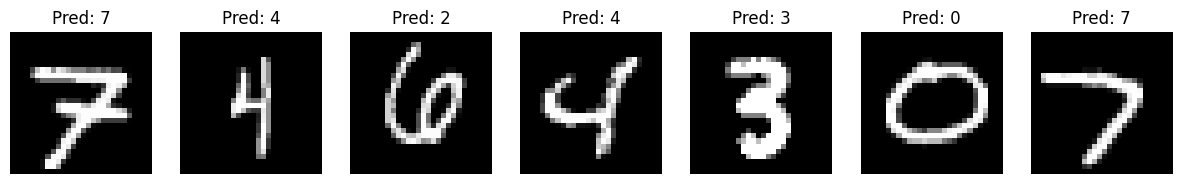

In [26]:
# Hiperparámetros
batch_size = 32
learning_rate = 0.001
n_epochs = 15

# Modelo, pérdida y optimizador
model = SimpleMLP().to('cpu')
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Entrenamiento
for epoch in range(n_epochs):
    model.train()
    for i in range(0, len(training_data), batch_size):
        x_batch = training_data[i:i+batch_size]
        y_batch = training_labels[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

# Evaluación
model.eval()
correct = 0
total = 0
fig, axes = plt.subplots(1, 7, figsize=(15, 5))  # Gráfico para mostrar 5 imágene
with torch.no_grad():
    for i in range(0, len(test_data), batch_size):
        x_batch = test_data[i:i+batch_size]
        y_batch = test_labels[i:i+batch_size]

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Visualizar 5 imágenes y sus salidas
        if i == 64:  # Mostrar solo las primeras 5 imágenes del primer batch
            for j in range(7):
                ax = axes[j]
                ax.imshow(x_batch[j].squeeze(), cmap='gray')
                ax.set_title(f'Pred: {predicted[j].item()}')
                ax.axis('off')

print(f"Precisión en el conjunto de prueba: {100 * correct / total:.2f}%")
plt.show()

-------------------------------------------------------------------------------------------------------------------------------------------------

# Ejercicio 7

Entrene un autoencoder para obtener una representación de baja dimensionalidad de las
imágenes de MNIST. Use dichas representaciones para entrenar un perceptrón
multicapa como clasificador. ¿Cuál es el tiempo de entrenamiento y la exactitud del
clasificador obtenido cuando parte de la representación del autoencoder, en
comparación con lo obtenido usando las imágenes originales?

Epoch 1/5, Loss: 0.001669
Epoch 2/5, Loss: 0.001103
Epoch 3/5, Loss: 0.000972
Epoch 4/5, Loss: 0.000919
Epoch 5/5, Loss: 0.000891


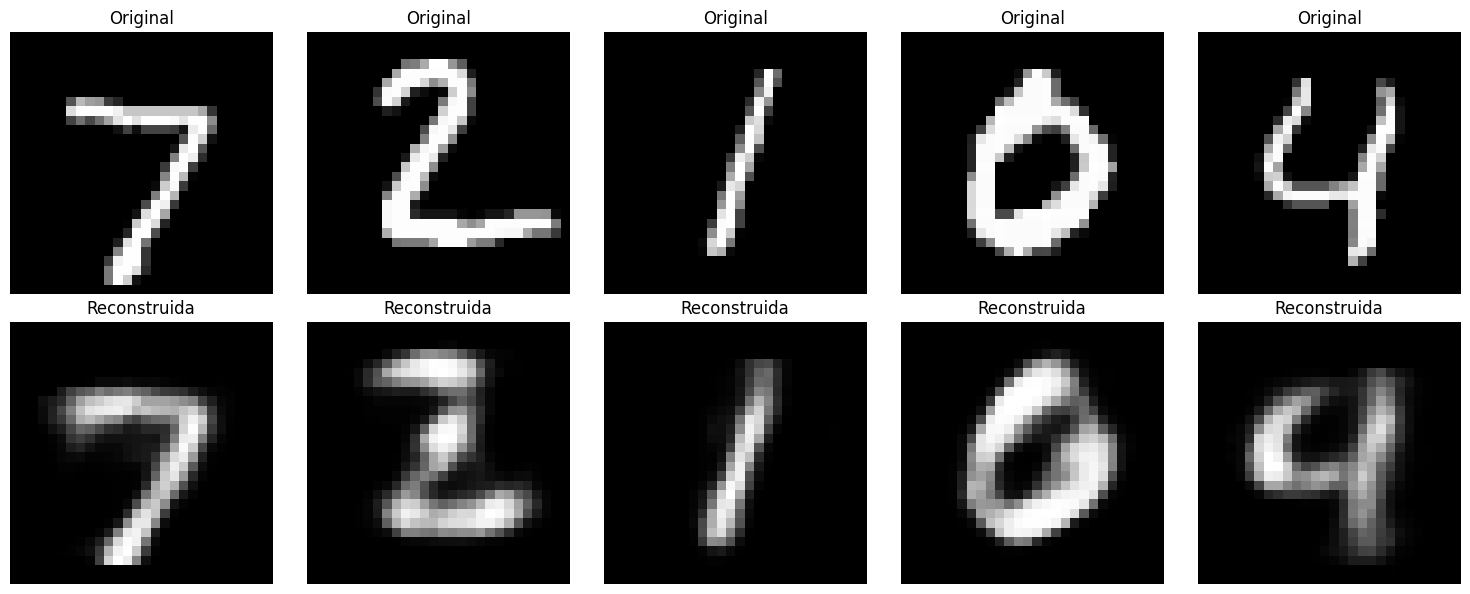

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.fc1 = nn.Linear(28*28, 30)
        self.fc2 = nn.Linear(30, 10)
        # Decoder
        self.fc3 = nn.Linear(10, 30)
        self.fc4 = nn.Linear(30, 28*28)

    def forward(self, x):
        x = torch.flatten(x, 1)         # Aplanar las imágenes
        x = F.relu(self.fc1(x))         # Codificación
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))         # Decodificación
        x = torch.sigmoid(self.fc4(x))  # Salida en rango [0, 1]
        return x

# Inicializar modelo, pérdida y optimizador
model = Autoencoder().to('cpu')
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Hiperparámetros
batch_size = 32
n_epochs = 5

# Datos (usa tus archivos .pt del MNIST proporcionados por el profe)
training_data = torch.load('MNIST_training_data.pt',weights_only=False).to(torch.float32)
training_labels = torch.load('MNIST_training_labels.pt',weights_only=False)
test_data = torch.load('MNIST_test_data.pt',weights_only=False).to(torch.float32)
test_labels = torch.load('MNIST_test_labels.pt',weights_only=False)

# Normalizar y redimensionar los datos
training_data = training_data / 255.0  # Normalizar entre 0 y 1
test_data = test_data / 255.0
training_data = training_data.unsqueeze(1)  # Agregar dimensión de canal
test_data = test_data.unsqueeze(1)


for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for i in range(0, len(training_data), batch_size):
        x_batch = training_data[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, x_batch.view(outputs.size()))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(training_data):.6f}")

# Evaluación y visualización
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # Mostrar originales y reconstrucciones
with torch.no_grad():
    x_test = test_data[:5]
    reconstructions = model(x_test)

    for i in range(5):
        # Imagen original
        axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        # Imagen reconstruida
        axes[1, i].imshow(reconstructions[i].view(28, 28).numpy(), cmap='gray')
        axes[1, i].set_title("Reconstruida")
        axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
import time

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_mlp(model, train_data, train_labels, test_data, test_labels, n_epochs=5, batch_size=32, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Tiempo de entrenamiento
    start_time = time.time()

    # Entrenamiento
    for epoch in range(n_epochs):
        model.train()
        for i in range(0, len(train_data), batch_size):
            x_batch = train_data[i:i+batch_size]
            y_batch = train_labels[i:i+batch_size]

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    training_time = end_time - start_time

    # Evaluación
    model.eval()
    correct = 0
    with torch.no_grad():
        for i in range(0, len(test_data), batch_size):
            x_batch = test_data[i:i+batch_size]
            y_batch = test_labels[i:i+batch_size]
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / len(test_data)

    return training_time, accuracy


# Extraer las representaciones comprimidas del autoencoder (encoder)
def get_compressed_representation(model, data):
    model.eval()
    with torch.no_grad():
        data_flat = data.view(data.size(0), -1)  # Aplanar las imágenes
        x = F.relu(model.fc1(data_flat))         # Codificación
        x = F.relu(model.fc2(x))
    return x

# Inicializar el MLP para las imágenes originales y las comprimidas
mlp_original = MLP(28*28, 10).to('cpu')  # 28*28 = 784 características, 10 clases
mlp_compressed = MLP(10, 10).to('cpu')  # 30 características comprimidas por el autoencoder

# 1. Entrenar el MLP con imágenes originales
print("Entrenando el MLP con imágenes originales...")
train_time_original, accuracy_original = train_mlp(mlp_original, training_data.view(-1, 28*28), training_labels, test_data.view(-1, 28*28), test_labels)

# 2. Obtener representaciones comprimidas y entrenar el MLP
print("Entrenando el MLP con representaciones comprimidas...")
compressed_train_data = get_compressed_representation(model, training_data)
compressed_test_data = get_compressed_representation(model, test_data)
train_time_compressed, accuracy_compressed = train_mlp(mlp_compressed, compressed_train_data, training_labels, compressed_test_data, test_labels)

# Resultados
print(f"\nTiempo de entrenamiento con imágenes originales: {train_time_original:.4f} segundos")
print(f"Exactitud con imágenes originales: {accuracy_original * 100:.2f}%")
print(f"\nTiempo de entrenamiento con representaciones comprimidas: {train_time_compressed:.4f} segundos")
print(f"Exactitud con representaciones comprimidas: {accuracy_compressed * 100:.2f}%")

Entrenando el MLP con imágenes originales...
Entrenando el MLP con representaciones comprimidas...

Tiempo de entrenamiento con imágenes originales: 9.6506 segundos
Exactitud con imágenes originales: 97.37%

Tiempo de entrenamiento con representaciones comprimidas: 7.7439 segundos
Exactitud con representaciones comprimidas: 89.48%


Resultados para MLP comprimido:


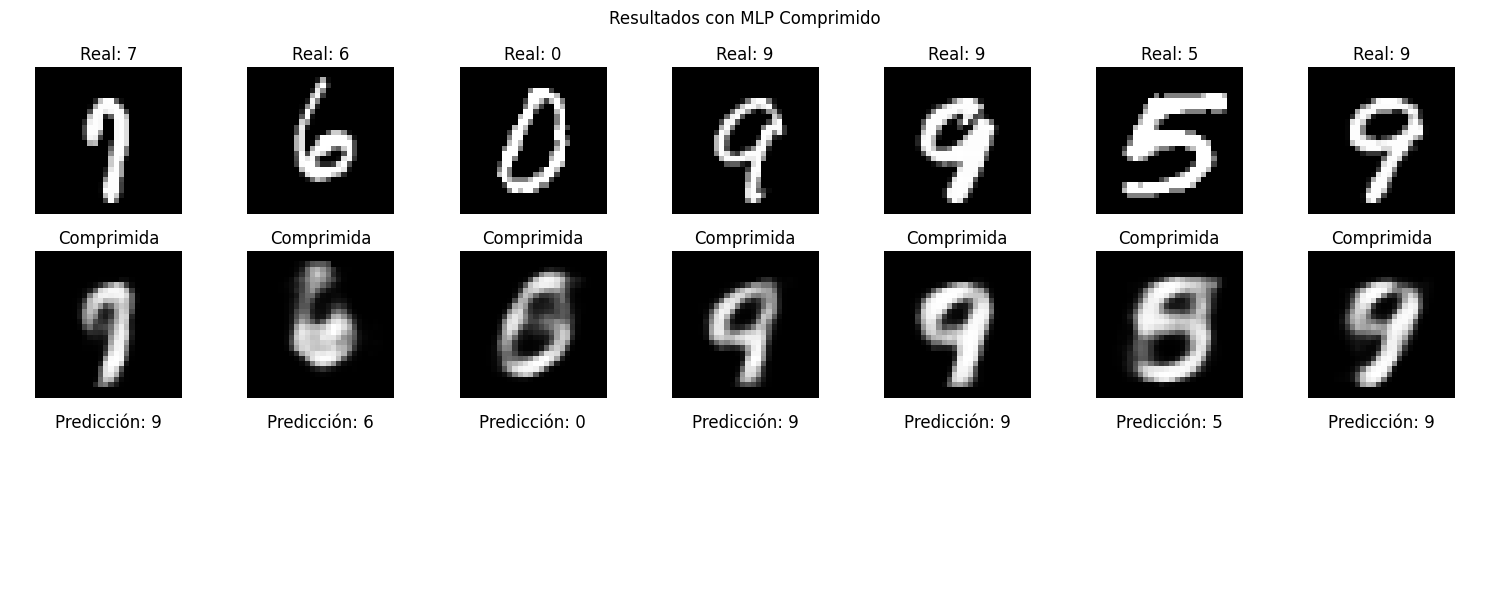

Resultados para MLP sin comprimir:


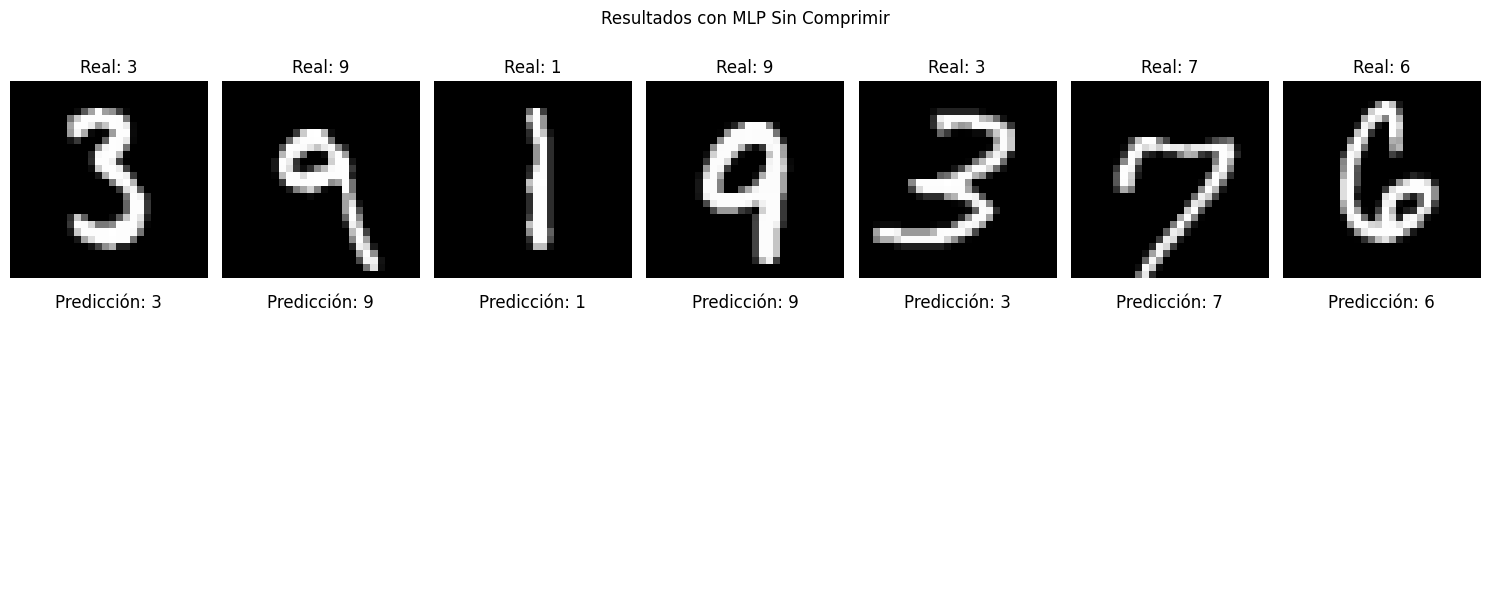

In [26]:
# Función para predecir y generar resultados
def predict_and_plot(mlp, data, labels, model_name, compressed_data=None):
    mlp.eval()
    fig, axes = plt.subplots(3 if compressed_data is not None else 2, 7, figsize=(15, 6))
    random_indices = random.sample(range(len(data)), 7)
    
    for idx, ax_idx in enumerate(random_indices):
        # Imagen original
        img = data[ax_idx].squeeze().detach().numpy()  # Asegurarse de que no requiere gradiente
        label = labels[ax_idx].item()

        # Entrada al modelo
        input_data = compressed_data[ax_idx].unsqueeze(0) if compressed_data is not None else data[ax_idx].view(1, -1)

        # Predicción del MLP
        with torch.no_grad():
            output = mlp(input_data)
            _, predicted_label = torch.max(output, 1)
            predicted_label = predicted_label.item()

        # Mostrar imagen original
        axes[0, idx].imshow(img, cmap="gray")
        axes[0, idx].axis('off')
        axes[0, idx].set_title(f"Real: {label}")

        if compressed_data is not None:
            # Imagen reconstruida por el autoencoder
            reconstructed_img = model(data[ax_idx:ax_idx+1])
            reconstructed_img = reconstructed_img.view(28, 28).detach().numpy()  # Desconectar del grafo
            axes[1, idx].imshow(reconstructed_img, cmap="gray")
            axes[1, idx].axis('off')
            axes[1, idx].set_title("Comprimida")

        # Mostrar predicción
        axes[2 if compressed_data is not None else 1, idx].text(0.5, 0.5, str( ),
                                                                fontsize=12, ha='center', va='center')
        axes[2 if compressed_data is not None else 1, idx].axis('off')
        axes[2 if compressed_data is not None else 1, idx].set_title(f"Predicción: {predicted_label}")

    plt.suptitle(f"Resultados con {model_name}")
    plt.tight_layout()
    plt.show()



# 1. Visualización para el MLP comprimido
print("Resultados para MLP comprimido:")
predict_and_plot(mlp_compressed, test_data, test_labels, "MLP Comprimido", compressed_data=compressed_test_data)

# 2. Visualización para el MLP sin comprimir
print("Resultados para MLP sin comprimir:")
predict_and_plot(mlp_original, test_data, test_labels, "MLP Sin Comprimir")



